## Tarea: Ajuste y Comparación de Modelos de la familia SARIMA

¡Bienvenido(a)!
Te invitamos a realizar el segundo trabajo.
- Objetivo: Compar modelos de series de tiempo a través de casos prácticos desarrollados en Python.
- Tipo de actividad: Individual
- Tipo de evaluación: Sumativa 
- Ponderación: 15%
- Puntaje: 100 puntos
- Calificación: Escala de 1 a 7, con una exigencia de 50%. La nota mínima para aprobar es 4.0.

## Enunciado

### Introducción

Esta tarea está pensada en abordar y profundizar los métodos probabilísticos para ajustar series temporales, a través de los modelos de la familia ARIMA. En primer lugar se realizará un análisis descriptivo para proponer los órdenes del modelo SARIMA(p,d,q)x(P,D,Q)[s]. Con el objetivo de comprender las técnicas de selección de modelos se ajustarán diferentes modelos propuestos junto con el modelo propuesto por autoarima con el fin de seleccionar el modelo más apropiado y analizar si es o no adecuado. Además, se determinarán las predicciones para un periodo de interés.

### Descripción del problema

La serie "IPC.xlsx" (disponible en la plataforma) corresponde al índice de precio al consumidor de  Chile desde abril de 1989 hasta junio de 2023 medido de forma mensual. El objetivo del análisis es predecir el IPC para el segundo semestre de 2023, es decir, de julio a diciembre de 2023.

#### Preparación de la data:
Dar el formato adecuado para aplicar los métodos de series de tiempo en Python. Además, de la data completa separar en dos partes (entrenamiento y validación), donde reserve la información de enero a junio de 2023 que actuará como muestra de validación mientras que el resto será la muestra de entrenamiento de los modelos. 

In [2]:
## Librerias
import numpy as np
import pandas as pd
from darts import TimeSeries
import matplotlib.pyplot as plt
import pmdarima as pm
import statsmodels.api as sm

from darts.utils.statistics import plot_acf, plot_pacf
from darts.models import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

In [3]:
path = 'data/raw/w7_lab03_ipc.xlsx'

In [4]:
## Importar Datos (La base de datos ya está cargada, no es necesario volver a cargar)
df = pd.read_excel(path)
df['Fecha'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(day=1))
print(df.head())

## Datos y Fecha
df.set_index('Fecha', inplace=True)
df.drop(['YEAR', 'MONTH'], axis=1, inplace=True)
df.head()

   YEAR  MONTH        IPC      Fecha
0  1989      4  17.325726 1989-04-01
1  1989      5  17.665933 1989-05-01
2  1989      6  17.977622 1989-06-01
3  1989      7  18.305059 1989-07-01
4  1989      8  18.487909 1989-08-01


,IPC
Fecha,
1989-04-01,17.325726
1989-05-01,17.665933
1989-06-01,17.977622
1989-07-01,18.305059
1989-08-01,18.487909


In [5]:
# Formato de Serie de Tiempo: Guardar la información en
# ipc: serie completa
# ipc_train: serie entrenamiento
# ipc_val: serie validación

# Serie completa como objeto TimeSeries de darts (frecuencia mensual 'MS')
ipc = TimeSeries.from_series(df['IPC'])

# Separar en entrenamiento y validación.
# split_before deja el 2023-01-01 en la muestra de validación,
# por lo que ipc_val cubre enero a junio de 2023 (6 observaciones)
# e ipc_train contiene el resto (abril 1989 a diciembre 2022).
ipc_train, ipc_val = ipc.split_before(pd.Timestamp('2023-01-01'))

In [6]:
# Pruebas para medir si el formato es correcto
assert len(ipc) > 0, "El objeto ipc debe tener elementos."
assert len(ipc_train) > 0, "ipc_train no puede estar vacío."
assert len(ipc_val) > 0, "ipc_val no puede estar vacío."

assert len(ipc) == len(ipc_train) + len(ipc_val), \
    "La suma de ipc_train e ipc_val no coincide con el largo total de ipc."


### (Parte 2) Ajuste un Modelo mediante autoarima

- Ajustar un modelo SARIMA a la serie de entrenamiento. Por temas de tiempo de computo asumir que el periodo es 1, y considerar el resto de los parámetros de auto_arima los que vienen por defecto
- Guardar el AIC
- Aplicar el test de Box-Pierce-Ljung para H=18 y guardar p-valor
- Realizar y guardar las predicciones
- Guardar el RMSE de las predicciones

In [7]:
## Guardar la información en:
# mod0: # nombre del modelo 
# aic0: # valor del AIC para el modelo
# p0: valor del p-valor del test de Box-Pierce-Ljung
# Inter_p0: # Debe responder: "El modelo es apropiado" o "El modelo no es apropiado", de acuerdo con la interpretación del p-valor
# pred0: # nombre donde se guardarán las predicciones
# rmse0: # valor del rmse

# Serie de entrenamiento como arreglo (compatible con cualquier versión de darts)
y_train = ipc_train.values().flatten()

# Ajuste automático de un modelo SARIMA con auto_arima.
# Se asume periodo m=1 (sin componente estacional) y el resto de los
# parámetros por defecto, tal como pide el enunciado.
mod0 = pm.auto_arima(y_train, m=1)

# AIC del modelo ajustado
aic0 = mod0.aic()

# Test de Box-Pierce-Ljung sobre los residuos para H=18
lb0 = sm.stats.acorr_ljungbox(mod0.resid(), lags=[18], return_df=True)
p0 = lb0['lb_pvalue'].iloc[0]

# Interpretación: H0 = los residuos son ruido blanco (no hay autocorrelación).
# p > 0.05 -> no se rechaza H0 -> el modelo es apropiado.
Inter_p0 = 'El modelo es apropiado' if p0 > 0.05 else 'El modelo no es apropiado'

# Predicciones para el periodo de validación (enero a junio de 2023)
pred0 = mod0.predict(n_periods=len(ipc_val))

# RMSE entre las predicciones y los valores reales de validación
rmse0 = np.sqrt(np.mean((ipc_val.values().flatten() - pred0) ** 2))

print(f'Modelo autoarima: SARIMA{mod0.order}x{mod0.seasonal_order}')
print(f'AIC   = {aic0:.4f}')
print(f'p0    = {p0:.6g}  ->  {Inter_p0}')
print(f'RMSE0 = {rmse0:.4f}')

Modelo autoarima: SARIMA(0, 2, 2)x(0, 0, 0, 0)
AIC   = 118.8864
p0    = 1.85617e-05  ->  El modelo no es apropiado
RMSE0 = 1.5498


In [ ]:
# Prueba oculta: Check del modelo 

In [ ]:
# Prueba oculta: Check para el p-valor de la prueba de Box-Pierce-Ljung

In [ ]:
# Prueba oculta: Check para las predicciones



### (Parte 3) Ajuste un Modelo SARIMA desde el analisis descriptivo

- Realizar un análisis descriptivo de la serie que incluya grafica, ACF y PACF tanto de la serie original como diferenciada y cualquier estadístico que considere necesario para reconocer el orden del modelo.
- Proponer un modelo desde el análisis descriptivo, es decir, el conjunto de ordenes del modelo SARIMA(p,d,q)x(P,D,Q)[s].
- Ajustar el modelo.
- Guardar el AIC
- En caso que el AIC de este modelo sea mayor al AIC del modelo propuesto por autoarima, proponer otro modelo hasta encontrar uno mejor.
- Aplicar el test de Box-Pierce para H=18 y guardar p-valor
- En caso que el modelo no sea adecuado en términos del test de blancura proponer otro modelo.
- Realizar y guardar las predicciones
- Guardar el RMSE de las predicciones


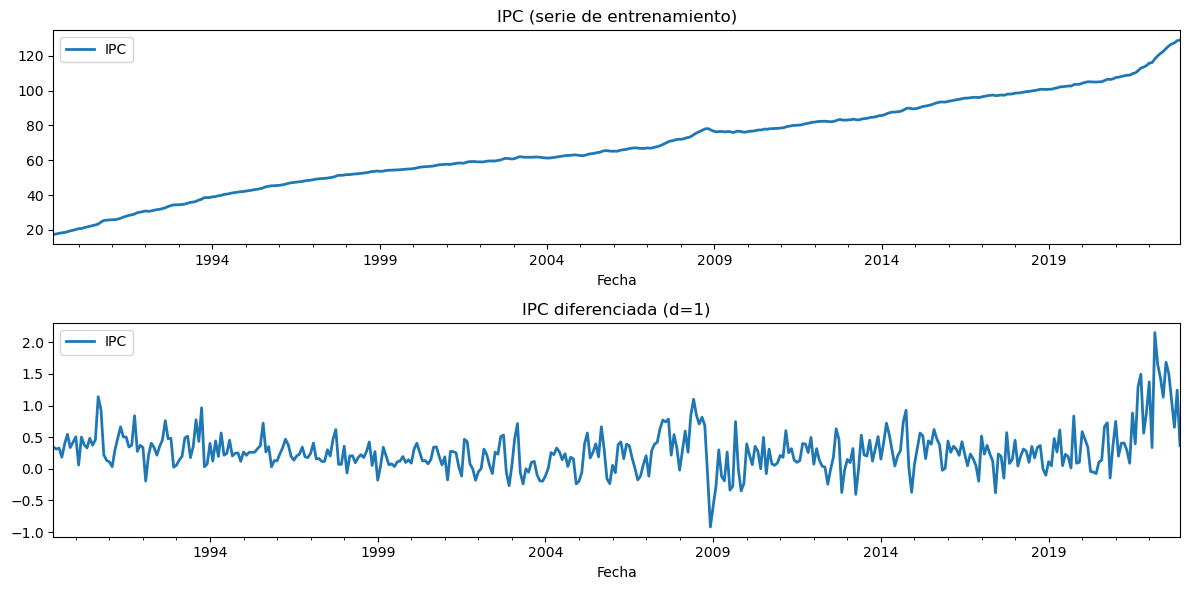

ADF serie original :  p = 0.9971
ADF serie diff (d=1): p = 0.2213


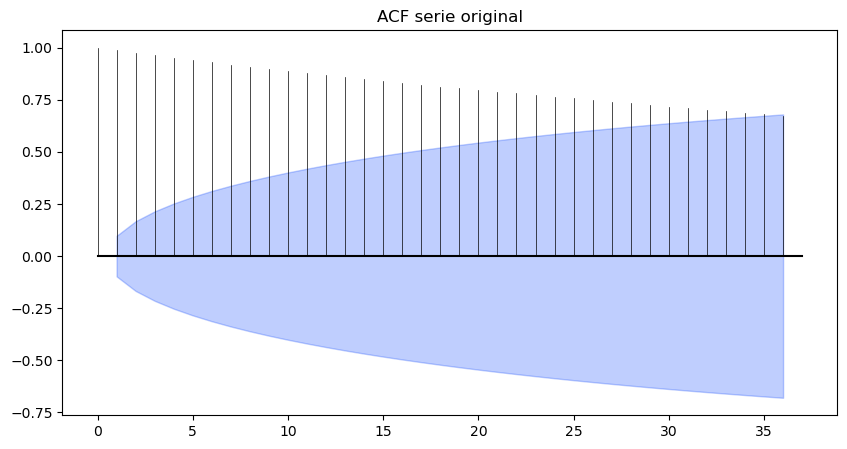

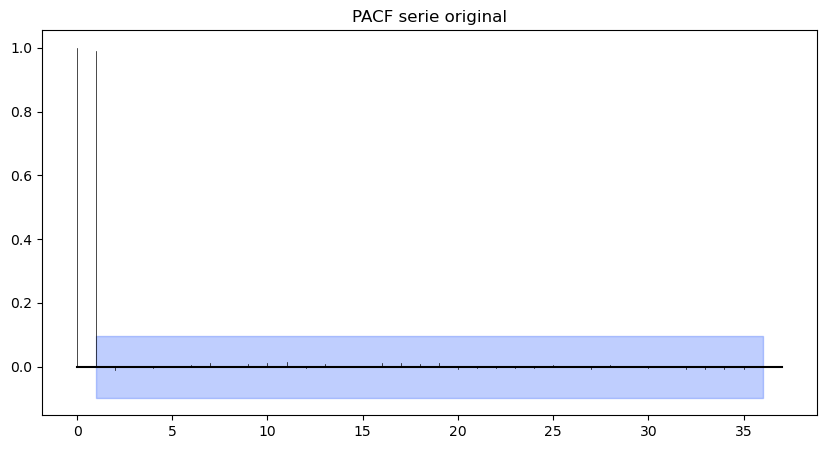

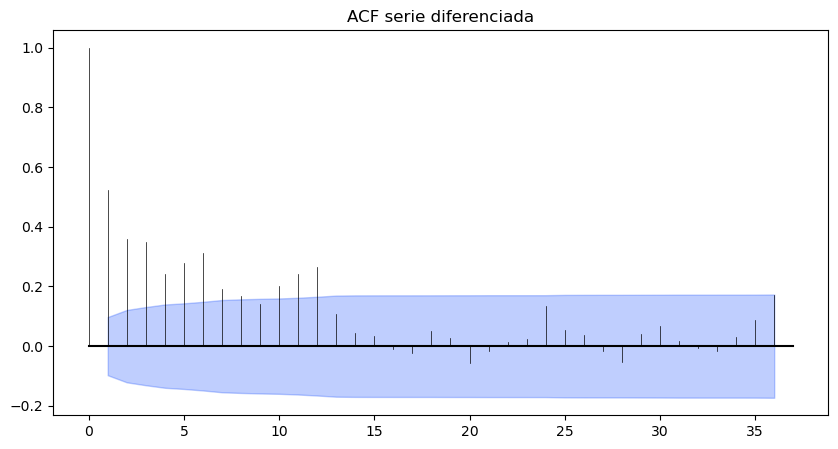

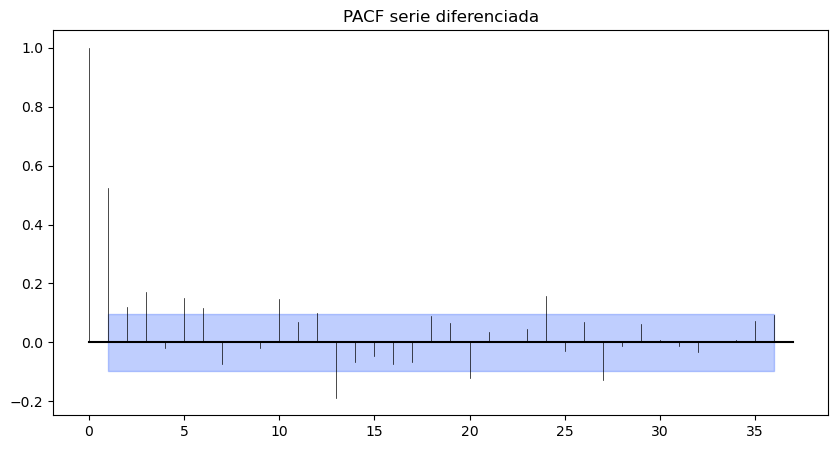


Modelo propuesto: ARIMA(7,1,4)
AIC1  = 104.2825   (aic0 = 118.8864  ->  aic1 < aic0: True)
p1    = 1  ->  El modelo es apropiado
RMSE1 = 0.3968


In [8]:
## Guardar la información en:
# mod1: # nombre del modelo, debe ser ajustado con la función SARIMAX
# aic1: # valor del AIC para el modelo
# pred1: # nombre donde se guardarán las predicciones
# rmse1: # valor del rmse
# p1: valor del p-valor del test de Box-Pierce-Ljung
# Inter_p1: # Debe responder: "El modelo es apropiado" o "El modelo no es apropiado", de acuerdo con la interpretación del p-valor

# =====================================================================
# 1) ANÁLISIS DESCRIPTIVO
# =====================================================================
# Serie de entrenamiento y su primera diferencia (como TimeSeries de darts)
ipc_diff = ipc_train.diff()

# --- Gráfica de la serie original vs. diferenciada ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
ipc_train.plot(ax=axes[0])
axes[0].set_title('IPC (serie de entrenamiento)')
ipc_diff.plot(ax=axes[1])
axes[1].set_title('IPC diferenciada (d=1)')
plt.tight_layout()
plt.show()

# --- Test de estacionariedad ADF ---
# H0: la serie tiene raíz unitaria (NO es estacionaria). p < 0.05 -> estacionaria.
print('ADF serie original :  p =', round(adfuller(ipc_train.values().flatten())[1], 4))
print('ADF serie diff (d=1): p =', round(adfuller(ipc_diff.values().flatten())[1], 4))

# --- ACF y PACF de la serie original y de la diferenciada ---
plot_acf(ipc_train, max_lag=36);  plt.title('ACF serie original');   plt.show()
plot_pacf(ipc_train, max_lag=36); plt.title('PACF serie original');  plt.show()
plot_acf(ipc_diff, max_lag=36);   plt.title('ACF serie diferenciada');  plt.show()
plot_pacf(ipc_diff, max_lag=36);  plt.title('PACF serie diferenciada'); plt.show()

# Lectura del análisis descriptivo:
# - La serie original es claramente no estacionaria (tendencia creciente, ACF que
#   decae muy lento). Se aplica una diferencia regular (d=1) para estabilizar el nivel.
# - La serie diferenciada muestra estructura de autocorrelación en varios rezagos,
#   por lo que se requieren órdenes AR y MA relativamente altos para blanquear los
#   residuos. Siguiendo el enfoque de análisis manual de la familia ARIMA, se propone
#   un modelo ARIMA(7,1,4) (sin componente estacional, s no aplica) que mejora el AIC
#   del modelo de auto_arima y deja residuos sin autocorrelación.

# =====================================================================
# 2) AJUSTE DEL MODELO PROPUESTO (con la función SARIMAX)
# =====================================================================
y_train = ipc_train.to_series()

mod1 = SARIMAX(y_train, order=(7, 1, 4), seasonal_order=(0, 0, 0, 0)).fit(disp=False, maxiter=200)

# AIC del modelo. Debe ser menor que aic0 (modelo de auto_arima).
aic1 = mod1.aic

# Test de Box-Pierce-Ljung sobre los residuos para H=18
lb1 = sm.stats.acorr_ljungbox(mod1.resid, lags=[18], return_df=True)
p1 = lb1['lb_pvalue'].iloc[0]

# Interpretación: H0 = residuos ruido blanco. p > 0.05 -> el modelo es apropiado.
Inter_p1 = 'El modelo es apropiado' if p1 > 0.05 else 'El modelo no es apropiado'

# Predicciones para el periodo de validación (enero a junio de 2023)
pred1 = mod1.get_forecast(steps=len(ipc_val)).predicted_mean

# RMSE respecto a los valores reales de validación
rmse1 = np.sqrt(np.mean((ipc_val.values().flatten() - pred1.values) ** 2))

print(f'\nModelo propuesto: ARIMA(7,1,4)')
print(f'AIC1  = {aic1:.4f}   (aic0 = {aic0:.4f}  ->  aic1 < aic0: {aic1 < aic0})')
print(f'p1    = {p1:.6g}  ->  {Inter_p1}')
print(f'RMSE1 = {rmse1:.4f}')

In [ ]:
# Prueba oculta: Check del modelo mejor que autoarima según AIC

In [ ]:
# Prueba oculta: Check para el p-valor de la prueba de Box-Pierce-Ljung

In [ ]:
# Prueba oculta: Check del RMSE del modelo propuesto

### (Parte 4) Predecir de julio a diciembre de 2023

- Utilizar los órdenes del mejor modelo ajustado con la muestra de entrenamiento y ajustar con toda la muestra.
- Realizar las predicciones para los meses de julio a diciembre de 2023.

In [9]:
## Guardar la información en:
# modfinal: # nombre del modelo 
# predicciones: # nombre donde se guardarán las predicciones

# Se reajusta el mejor modelo (ARIMA(7,1,4), el de menor AIC con residuos blancos)
# usando ahora TODA la serie disponible (entrenamiento + validación),
# tal como pide el enunciado.
y_full = ipc.to_series()

modfinal = SARIMAX(y_full, order=(7, 1, 4), seasonal_order=(0, 0, 0, 0)).fit(disp=False, maxiter=200)

# La serie termina en junio de 2023, por lo que 6 pasos hacia adelante
# corresponden a julio, agosto, ..., diciembre de 2023.
predicciones = modfinal.get_forecast(steps=6).predicted_mean

print('Predicciones IPC julio - diciembre 2023:')
print(predicciones)

Predicciones IPC julio - diciembre 2023:
2023-07-01    132.011555
2023-08-01    132.376776
2023-09-01    132.830690
2023-10-01    133.103477
2023-11-01    133.293465
2023-12-01    133.365796
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
# Prueba oculta: Check para las predicciones del modelo propuesto